## 1. Import Library

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

df = pd.read_csv("gallstone_dataset.csv")
df.head()


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [7]:
print(f'mssing: {df.isnull().sum()}')
print(f"dupe: {df.duplicated().sum()}")


mssing: Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)                         0
Bone

In [ ]:
print(df["Gallstone Status"].value_counts())
# print(df["Gallstone Status"].value_counts(normalize=True).round(3) * 100, "%")

Gallstone Status
0    161
1    158
Name: count, dtype: int64
Gallstone Status
0    50.5
1    49.5
Name: proportion, dtype: float64 %


In [15]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50


In [16]:

X_full = df.drop(columns=["Gallstone Status"])
y_full = df["Gallstone Status"]

f_scores, p_values = f_classif(X_full, y_full)
importance_df = pd.DataFrame({
    "Feature": X_full.columns,
    "F-score": f_scores,
    "p-value": p_values
}).sort_values("F-score", ascending=False).reset_index(drop=True)

importance_df.head(15)

,Feature,F-score,p-value
0,Vitamin D,45.673154,6.709802e-11
1,C-Reactive Protein (CRP),27.385949,3.037234e-07
2,Lean Mass (LM) (%),17.022706,4.725017e-05
3,Total Body Fat Ratio (TBFR) (%),16.978389,4.830830e-05
4,Bone Mass (BM),15.599719,9.649236e-05
5,Hemoglobin (HGB),12.781941,4.045010e-04
6,Extracellular Water (ECW),10.425070,1.373387e-03
7,Total Fat Content (TFC),9.451995,2.292569e-03
8,Extracellular Fluid/Total Body Water (ECF/TBW),9.414047,2.339084e-03
9,Hyperlipidemia,8.532832,3.738263e-03


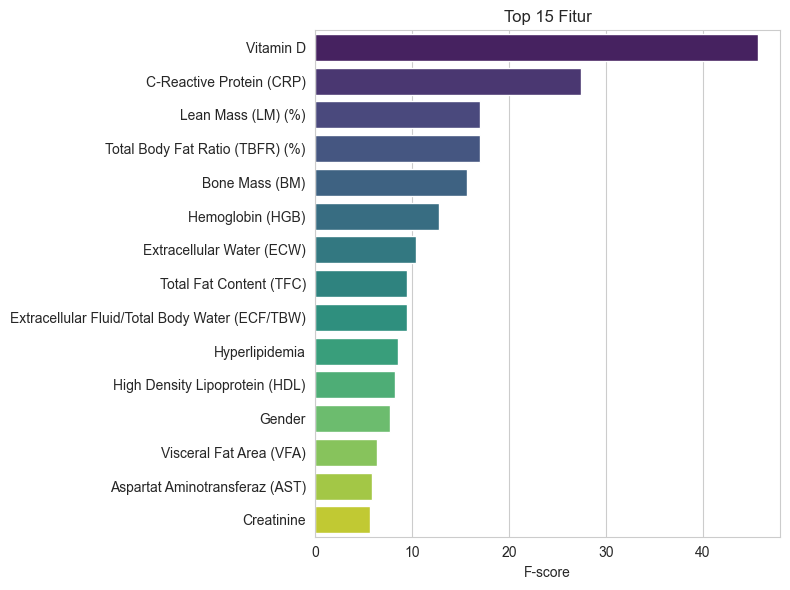

In [ ]:

plt.figure(figsize=(8, 6))
top15 = importance_df.head(15)
sns.barplot(data=top15, y="Feature", x="F-score", palette="viridis")
plt.title("Top 15 Fitur")
plt.xlabel("F-score")
plt.ylabel("")
plt.tight_layout()
plt.show()

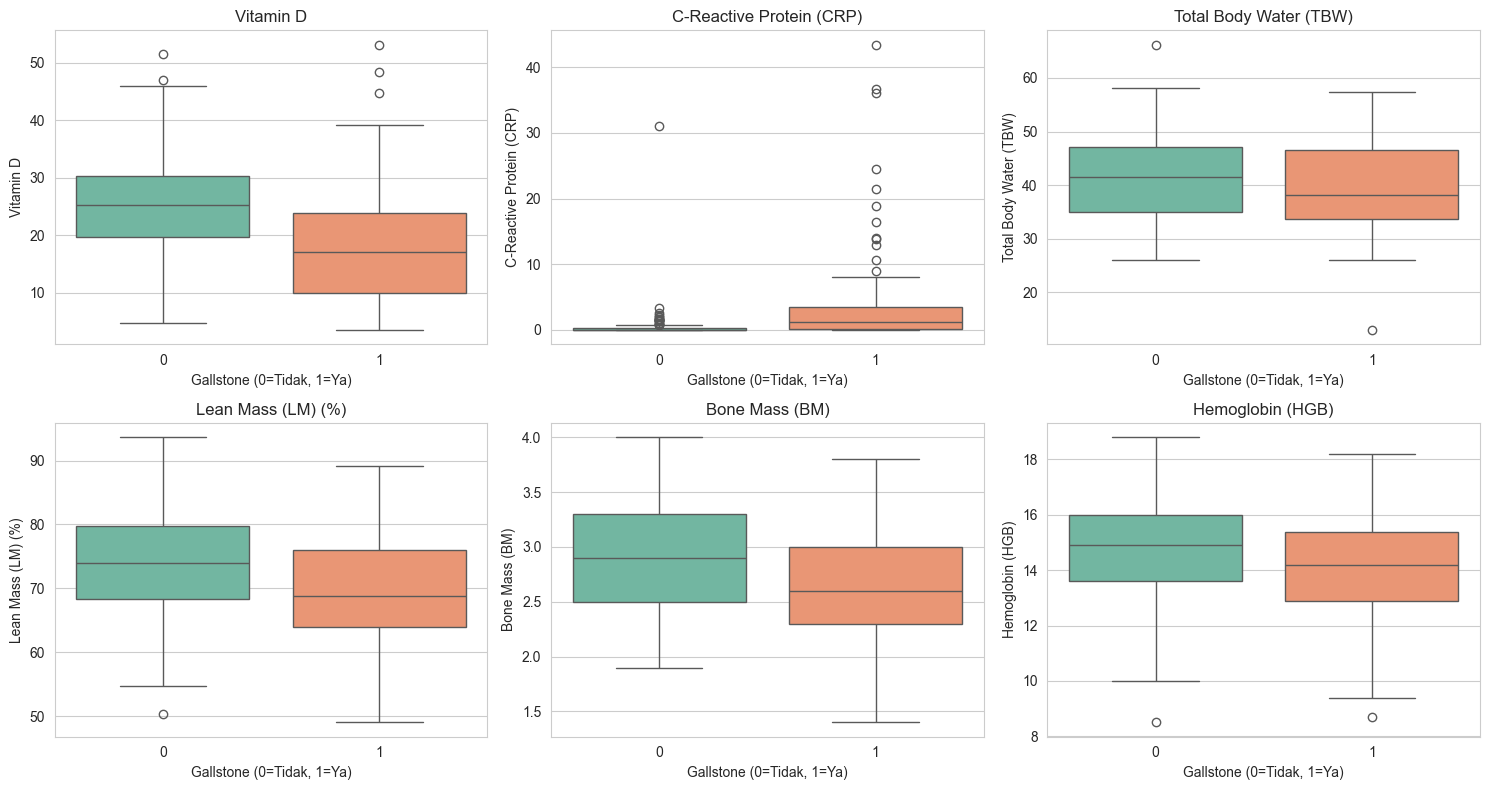

In [18]:

key_features = [
    "Vitamin D", "C-Reactive Protein (CRP)", "Total Body Water (TBW)",
    "Lean Mass (LM) (%)", "Bone Mass (BM)", "Hemoglobin (HGB)"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x="Gallstone Status", y=feat, ax=ax, palette="Set2")
    ax.set_title(feat)
    ax.set_xlabel("Gallstone (0=Tidak, 1=Ya)")

plt.tight_layout()
plt.show()


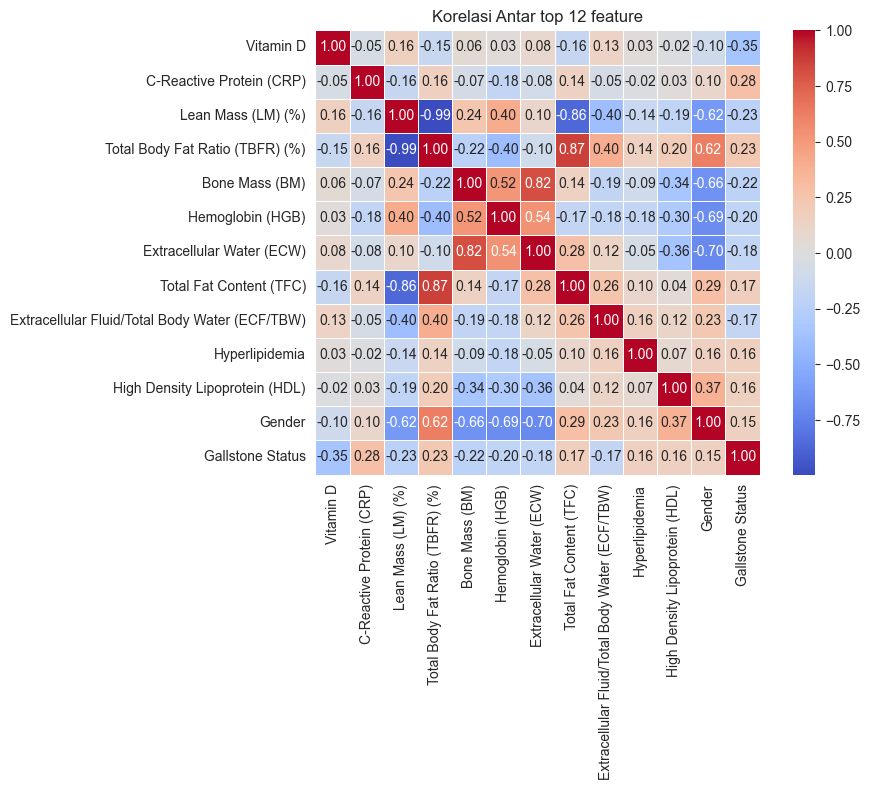

In [19]:

subset_cols = importance_df.head(12)["Feature"].tolist() + ["Gallstone Status"]
corr = df[subset_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Korelasi Antar top 12 feature")
plt.tight_layout()
plt.show()


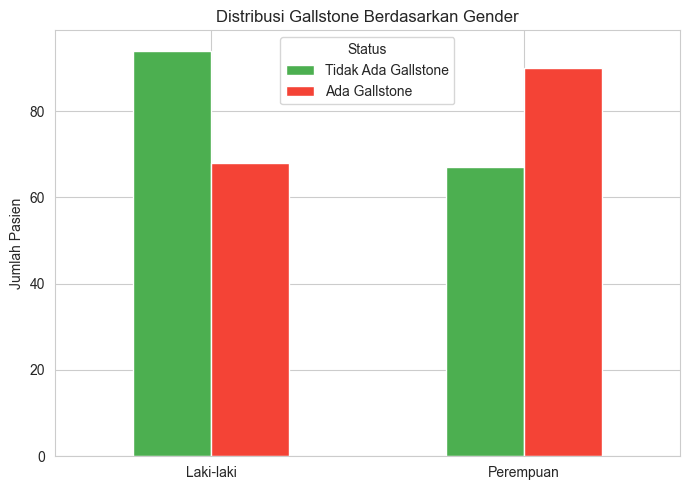

In [21]:

gender_gallstone = df.groupby(["Gender", "Gallstone Status"]).size().unstack()
gender_gallstone.index = ["Laki-laki" if g == 0 else "Perempuan" for g in gender_gallstone.index]
gender_gallstone.columns = ["Tidak Ada Gallstone", "Ada Gallstone"]

gender_gallstone.plot(kind="bar", figsize=(7, 5), color=["#4CAF50", "#F44336"])
plt.title("Distribusi Gallstone Berdasarkan Gender")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()


In [22]:

SELECTED_FEATURES = [
    "Vitamin D",
    "C-Reactive Protein (CRP)",
    "Total Body Water (TBW)",
    "Lean Mass (LM) (%)",
    "Total Body Fat Ratio (TBFR) (%)",
    "Bone Mass (BM)",
    "Hemoglobin (HGB)",
    "Extracellular Water (ECW)",
    "Total Fat Content (TFC)",
]

X = df[SELECTED_FEATURES].copy()
y = df["Gallstone Status"].copy()

print(f"Jumlah fitur yang dipakai untuk modeling: {X.shape[1]}")
X.head()


Jumlah fitur yang dipakai untuk modeling: 9


,Vitamin D,C-Reactive Protein (CRP),Total Body Water (TBW),Lean Mass (LM) (%),Total Body Fat Ratio (TBFR) (%),Bone Mass (BM),Hemoglobin (HGB),Extracellular Water (ECW),Total Fat Content (TFC)
0,33.0,0.0,52.9,80.84,19.2,3.7,16.0,21.2,17.8
1,25.0,0.0,43.1,67.20,32.8,3.2,14.4,19.5,31.0
2,30.2,0.0,47.2,72.67,27.3,3.3,16.2,20.1,24.9
3,35.4,0.0,41.4,84.19,15.8,2.9,15.4,17.0,10.7
4,40.6,0.0,51.4,80.02,20.0,3.5,16.8,20.0,17.9


## Train-Test Split & Cross-Validation

In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Data training(CV) : {X_train.shape[0]} baris")
print(f"Data hold-out test: {X_test.shape[0]} baris")

print(f"Distribusi target di training: {y_train.value_counts().to_dict()}")
print(f"Distribusi target di test    : {y_test.value_counts().to_dict()}")


Data training(CV) : 255 baris
Data hold-out test: 64 baris
Distribusi target di training: {0: 129, 1: 126}
Distribusi target di test    : {1: 32, 0: 32}


In [26]:

N_SPLITS = 10
N_REPEATS = 5  

def evaluate_model(model, X, y, n_splits=N_SPLITS, n_repeats=N_REPEATS):
    from sklearn.base import clone

    metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "auc": []}

    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=repeat)
        for train_idx, test_idx in skf.split(X, y):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_te)
            y_proba = m.predict_proba(X_te)[:, 1]

            metrics["accuracy"].append(accuracy_score(y_te, y_pred))
            metrics["precision"].append(precision_score(y_te, y_pred, zero_division=0))
            metrics["recall"].append(recall_score(y_te, y_pred, zero_division=0))
            metrics["f1"].append(f1_score(y_te, y_pred, zero_division=0))
            metrics["auc"].append(roc_auc_score(y_te, y_proba))

    summary = {}
    for key, values in metrics.items():
        values = np.array(values)
        summary[key] = {"mean": values.mean(), "std": values.std(),
                         "min": values.min(), "max": values.max(), "raw": values}
    return summary


## 7.Logistic Regression

In [28]:

model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

result_lr = evaluate_model(model_lr, X_train, y_train)

print("Logistic Regression:")
print(f"Akurasi : {result_lr['accuracy']['mean']:.4f}")
print(f"Precision: {result_lr['precision']['mean']:.4f}")
print(f"Recall   : {result_lr['recall']['mean']:.4f}")
print(f"F1-score : {result_lr['f1']['mean']:.4f}")
print(f"AUC      : {result_lr['auc']['mean']:.4f}")



Logistic Regression:
Akurasi : 0.7662
Precision: 0.7964
Recall   : 0.7167
F1-score : 0.7487
AUC      : 0.8192



## 8.Random Forest


In [30]:

model_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)

result_rf = evaluate_model(model_rf, X_train, y_train)

print("Random Forest:")
print(f"Akurasi : {result_rf['accuracy']['mean']:.4f}")
print(f"Precision: {result_rf['precision']['mean']:.4f}")
print(f"Recall   : {result_rf['recall']['mean']:.4f}")
print(f"F1-score : {result_rf['f1']['mean']:.4f}")
print(f"AUC      : {result_rf['auc']['mean']:.4f}")



Random Forest:
Akurasi : 0.7842
Precision: 0.8033
Recall   : 0.7605
F1-score : 0.7774
AUC      : 0.8472


## Gradient Boosting

In [32]:

model_gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

result_gb = evaluate_model(model_gb, X_train, y_train)

print("Gradient Boosting:")
print(f"Akurasi : {result_gb['accuracy']['mean']:.4f}")
print(f"Precision: {result_gb['precision']['mean']:.4f}")
print(f"Recall   : {result_gb['recall']['mean']:.4f}")
print(f"F1-score : {result_gb['f1']['mean']:.4f}")
print(f"AUC      : {result_gb['auc']['mean']:.4f}")

Gradient Boosting:
Akurasi : 0.7566
Precision: 0.7658
Recall   : 0.7440
F1-score : 0.7500
AUC      : 0.8253



## Support Vector Machine


In [33]:

model_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])

result_svm = evaluate_model(model_svm, X_train, y_train)

print("SVM:")
print(f"Akurasi : {result_svm['accuracy']['mean']:.4f}")
print(f"Precision: {result_svm['precision']['mean']:.4f}")
print(f"Recall   : {result_svm['recall']['mean']:.4f}")
print(f"F1-score : {result_svm['f1']['mean']:.4f}")
print(f"AUC      : {result_svm['auc']['mean']:.4f}")



SVM:
Akurasi : 0.7322
Precision: 0.7784
Recall   : 0.6528
F1-score : 0.7034
AUC      : 0.8150



## 11. Perbandingan Semua Model


In [34]:

all_results = {
    "Logistic Regression": result_lr,
    "Random Forest": result_rf,
    "Gradient Boosting": result_gb,
    "SVM (RBF)": result_svm,
}

comparison_df = pd.DataFrame({
    name: {
        "Akurasi (mean)": res["accuracy"]["mean"],
        "Akurasi (std)": res["accuracy"]["std"],
        "Precision": res["precision"]["mean"],
        "Recall": res["recall"]["mean"],
        "F1-score": res["f1"]["mean"],
        "AUC": res["auc"]["mean"],
    }
    for name, res in all_results.items()
}).T.round(4)

comparison_df.sort_values("Akurasi (mean)", ascending=False)


,Akurasi (mean),Akurasi (std),Precision,Recall,F1-score,AUC
Random Forest,0.7842,0.0743,0.8033,0.7605,0.7774,0.8472
Logistic Regression,0.7662,0.0717,0.7964,0.7167,0.7487,0.8192
Gradient Boosting,0.7566,0.0776,0.7658,0.7440,0.7500,0.8253
SVM (RBF),0.7322,0.0734,0.7784,0.6528,0.7034,0.8150


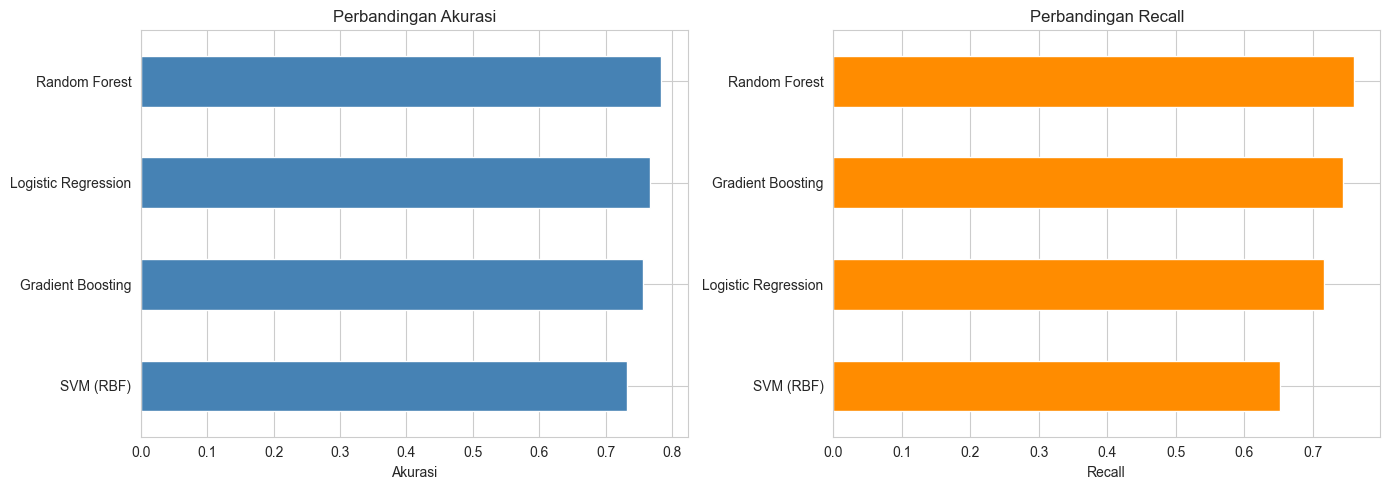

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_df["Akurasi (mean)"].sort_values().plot(
    kind="barh", ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Perbandingan Akurasi")
axes[0].set_xlabel("Akurasi")

comparison_df["Recall"].sort_values().plot(
    kind="barh", ax=axes[1], color="darkorange"
)
axes[1].set_title("Perbandingan Recall")
axes[1].set_xlabel("Recall")

plt.tight_layout()
plt.show()

In [49]:
 
best_model_name = comparison_df["Recall"].idxmax()
print(f"Model terbaik berdasarkan recall: {best_model_name}")
print(f"Akurasi: {comparison_df.loc[best_model_name, 'Recall']:.4f}")


Model terbaik berdasarkan recall: Random Forest
Akurasi: 0.7605



## 12. Evaluasi Final 


In [51]:

models_dict = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb,
    "SVM (RBF)": model_svm,
}

final_model = models_dict[best_model_name]
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, zero_division=0)
final_recall = recall_score(y_test, y_pred, zero_division=0)
final_f1 = f1_score(y_test, y_pred, zero_division=0)
final_auc = roc_auc_score(y_test, y_proba)

print(f"Evaluasi Final: {best_model_name}")
print(f"Akurasi  : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"AUC      : {final_auc:.4f}")


Evaluasi Final: Random Forest
Akurasi  : 0.7969
Precision: 0.8065
Recall   : 0.7812
F1-score : 0.7937
AUC      : 0.8604


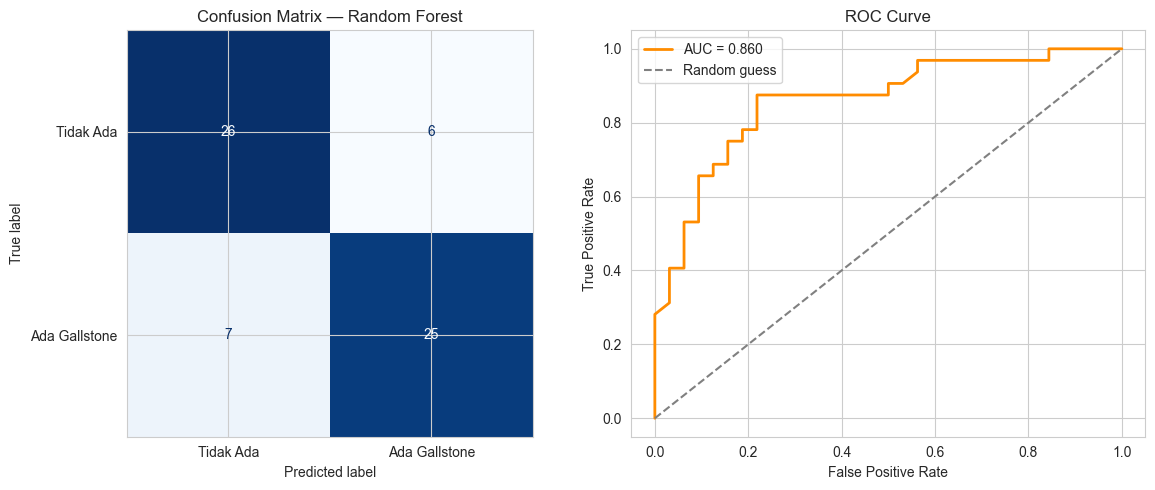

In [52]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tidak Ada", "Ada Gallstone"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {final_auc:.3f}", color="darkorange", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()



## Simpan Model Final


In [53]:

joblib.dump(final_model, "gallstone_model.joblib")

metadata = {
    "model": best_model_name,
    "accuracy": final_accuracy,
    "precision": final_precision,
    "recall": final_recall,
    "f1": final_f1,
    "auc": final_auc,
    "confusion_matrix": cm.tolist(),
    "n_test_samples": int(len(y_test)),
    "cv_accuracy_mean": float(comparison_df.loc[best_model_name, "Akurasi (mean)"]),
    "cv_accuracy_std": float(comparison_df.loc[best_model_name, "Akurasi (std)"]),
    "features_used": SELECTED_FEATURES,
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))


{
  "model": "Random Forest",
  "accuracy": 0.796875,
  "precision": 0.8064516129032258,
  "recall": 0.78125,
  "f1": 0.7936507936507936,
  "auc": 0.8603515625,
  "confusion_matrix": [
    [
      26,
      6
    ],
    [
      7,
      25
    ]
  ],
  "n_test_samples": 64,
  "cv_accuracy_mean": 0.7842,
  "cv_accuracy_std": 0.0743,
  "features_used": [
    "Vitamin D",
    "C-Reactive Protein (CRP)",
    "Total Body Water (TBW)",
    "Lean Mass (LM) (%)",
    "Total Body Fat Ratio (TBFR) (%)",
    "Bone Mass (BM)",
    "Hemoglobin (HGB)",
    "Extracellular Water (ECW)",
    "Total Fat Content (TFC)"
  ]
}
